In [1]:
import sys
print(sys.executable)

c:\Users\Alvin\anaconda3\python.exe


In [2]:
#all genes

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# -------------------------------
# CONFIGURATION
# -------------------------------
seed = 0
np.random.seed(seed)

# Load data
X_train = pd.read_csv("../../Datasets/X_train_purified.csv")
X_test = pd.read_csv("../../Datasets/X_test_purified.csv")
y_train = pd.read_csv("../../Datasets/Y_train_purified.csv").values.ravel()
y_test = pd.read_csv("../../Datasets/Y_test_purified.csv").values.ravel()

# Label encode
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
n_classes = len(le.classes_)

# -------------------------------
# AUTOENCODER (fixed)
# -------------------------------
def build_autoencoder(input_dim, encoding_dim=500, hidden_dim1=5000, hidden_dim2=2000, 
                      l2_reg=1e-14, learning_rate=3e-5):
    """Build encoder + autoencoder"""
    inp = Input(shape=(input_dim,))
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = ReLU()(x)
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    encoded = Dense(encoding_dim, kernel_regularizer=regularizers.l2(l2_reg))(x)
    encoded = ReLU()(encoded)
    
    # Decoder
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(encoded)
    x = ReLU()(x)
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    decoded = Dense(input_dim, activation='linear')(x)
    
    autoencoder = Model(inputs=inp, outputs=decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['accuracy'])
    
    encoder = Model(inputs=inp, outputs=encoded)
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(X_train.shape[1])
autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, verbose=1, shuffle=True)

# Encode features
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)



Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.0000e+00 - loss: 0.1351
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0000e+00 - loss: 0.0181
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.0142 - loss: 0.0088
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0142 - loss: 0.0076
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0425 - loss: 0.0074
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0810 - loss: 0.0073
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0850 - loss: 0.0073
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0850 - loss: 0.0073
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0709 - loss: 0.0073
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0810 - loss: 0.0072
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0607 - loss: 0.0071
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - a

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.910, test=0.866) total time=   9.0s
[CV 2/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.926, test=0.793) total time=   8.8s
[CV 3/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.913, test=0.732) total time=   7.7s
[CV 4/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, model__hidden_dim=200, model__learning_rate=0.0001;, score=(train=0.916, test=0.785) total time=   8.6s
[CV 5/5] END batch_size=16, model__activation=tanh, model__dropout_rate1=0.1, model__dropout_rate2=0.3, mo

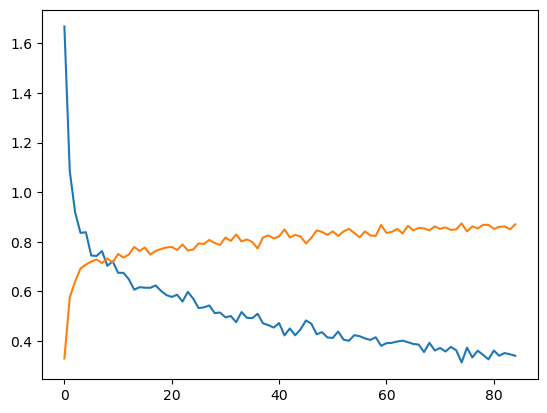


Classification Report:
              precision    recall  f1-score   support

       Basal       0.88      0.88      0.88        17
        Her2       0.50      0.50      0.50         6
        LumA       0.80      0.77      0.79        57
        LumB       0.59      0.62      0.60        26
      Normal       0.83      0.88      0.86        17

    accuracy                           0.76       123
   macro avg       0.72      0.73      0.73       123
weighted avg       0.76      0.76      0.76       123



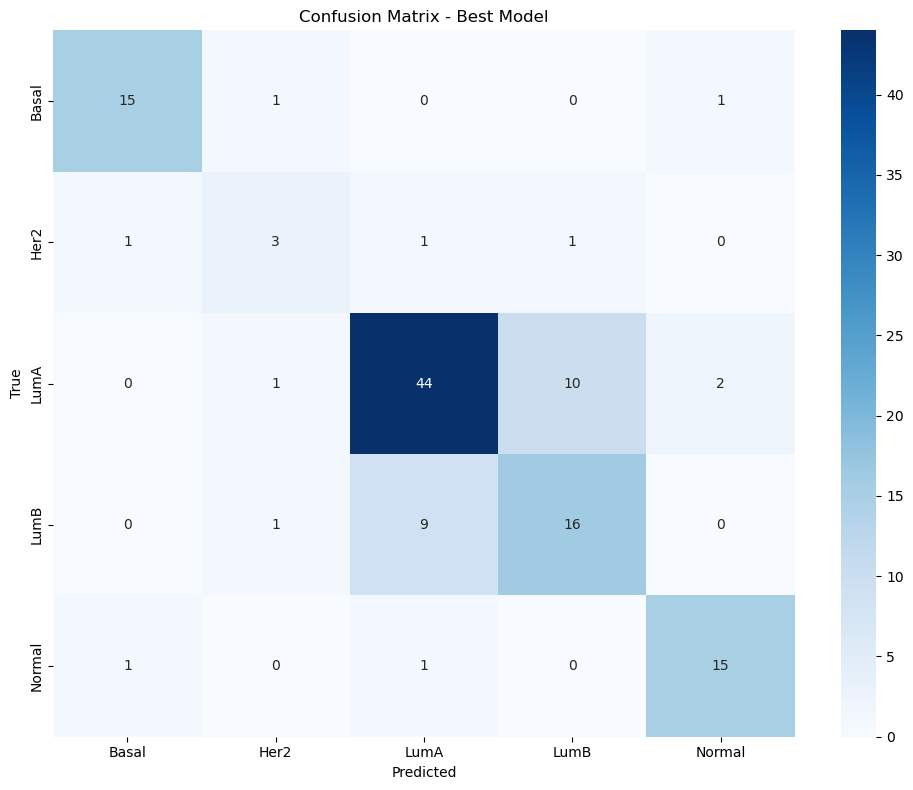


TOP 10 CONFIGURATIONS:

Rank 1:
  Score: 0.7995 (+/- 0.0385)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.1, 'model__dropout_rate1': 0.3, 'model__activation': 'tanh', 'batch_size': 16}

Rank 2:
  Score: 0.7942 (+/- 0.0428)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.3, 'model__dropout_rate1': 0.1, 'model__activation': 'tanh', 'batch_size': 16}

Rank 3:
  Score: 0.7935 (+/- 0.0367)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.1, 'model__dropout_rate1': 0.1, 'model__activation': 'tanh', 'batch_size': 32}

Rank 4:
  Score: 0.7918 (+/- 0.0492)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.4, 'model__dropout_rate1': 0.1, 'model__activation': 'relu', 'batch_size': 16}

Rank 5:
  Score: 0.7878 (+/- 0.0267)
  Parameters: {'model__learning_rate': 0.0001, 'model__hidden_dim': 200, '

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import StratifiedKFold
import joblib
import tensorflow as tf

class HistoryLogger(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        # This will stay attached to the model after RandomizedSearchCV finishes
        self.model.final_history = self.model.history.history
# -------------------------------
# CLASSIFIER
# -------------------------------

def create_classifier(hidden_dim=200, dropout_rate1=0.2, dropout_rate2=0.3, 
                      learning_rate=2e-5, activation='relu'):
    inp = Input(shape=(X_train_encoded.shape[1],))
    x = BatchNormalization()(inp)
    x = Dropout(dropout_rate1, seed=seed)(x)

    # Activation
    if activation == 'leakyrelu':
        x = Dense(hidden_dim)(x)
        x = LeakyReLU(negative_slope=0.01)(x)
    elif activation == 'relu':
        x = Dense(hidden_dim)(x)
        x = ReLU()(x)
    else:
        x = Dense(hidden_dim, activation='tanh')(x)

    x = BatchNormalization()(x)
    x = Dropout(dropout_rate2, seed=seed)(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap with KerasClassifier
clf = KerasClassifier(
    model=create_classifier,
    epochs=100, 
    verbose=0,
    loss='sparse_categorical_crossentropy',
    random_state=seed,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True), HistoryLogger()]

)

# -------------------------------
# RANDOMIZED SEARCH
# -------------------------------
param_dist = {
    'model__hidden_dim': [200],
    'model__dropout_rate1': [0.1, 0.2, 0.3],
    'model__dropout_rate2': [0.1, 0.2, 0.3, 0.4, 0.5],
    'model__learning_rate': [0.01, 0.002, 0.001, 0.0001],
    'model__activation': ['relu', 'tanh', 'leakyrelu'],
    'batch_size': [16, 32, 64],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=cv_strat,
    n_jobs=1,  
    random_state=seed,
    return_train_score=True,
    verbose=3
)

start = time.time()
random_search.fit(X_train_encoded, y_train_enc)
end = time.time()
print(f"RandomizedSearchCV completed in {(end-start)/60:.2f} minutes")

# -------------------------------
# EVALUATION
# -------------------------------
# Test on held-out test set
test_acc = random_search.score(X_test_encoded, y_test_enc)
print(f"Test set Score: {test_acc:.4f}")

best_model = random_search.best_estimator_
final_history = best_model.model_.final_history


joblib.dump(best_model, "NN_RS_AE_Purified_bestmodel.pkl")
print("Best estimator saved to 'NN_RS_AE_Purified_bestmodel.pkl'")

plt.plot(final_history['loss'], label='Loss')
plt.plot(final_history['accuracy'], label='Accuracy')
plt.show()

# Predict class labels
y_pred_classes = best_model.predict(X_test_encoded)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()

# Create results dataframe
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# Show top 10 configurations
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS:")
print("="*80)
top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
for idx, row in top_10.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Parameters: {row['params']}")


Test Score (Best Neural Network): 0.7565

Classification Report (Fixed Classifier):
              precision    recall  f1-score   support

       Basal       0.88      0.88      0.88        17
        Her2       0.50      0.50      0.50         6
        LumA       0.80      0.77      0.79        57
        LumB       0.59      0.62      0.60        26
      Normal       0.83      0.88      0.86        17

    accuracy                           0.76       123
   macro avg       0.72      0.73      0.73       123
weighted avg       0.76      0.76      0.76       123



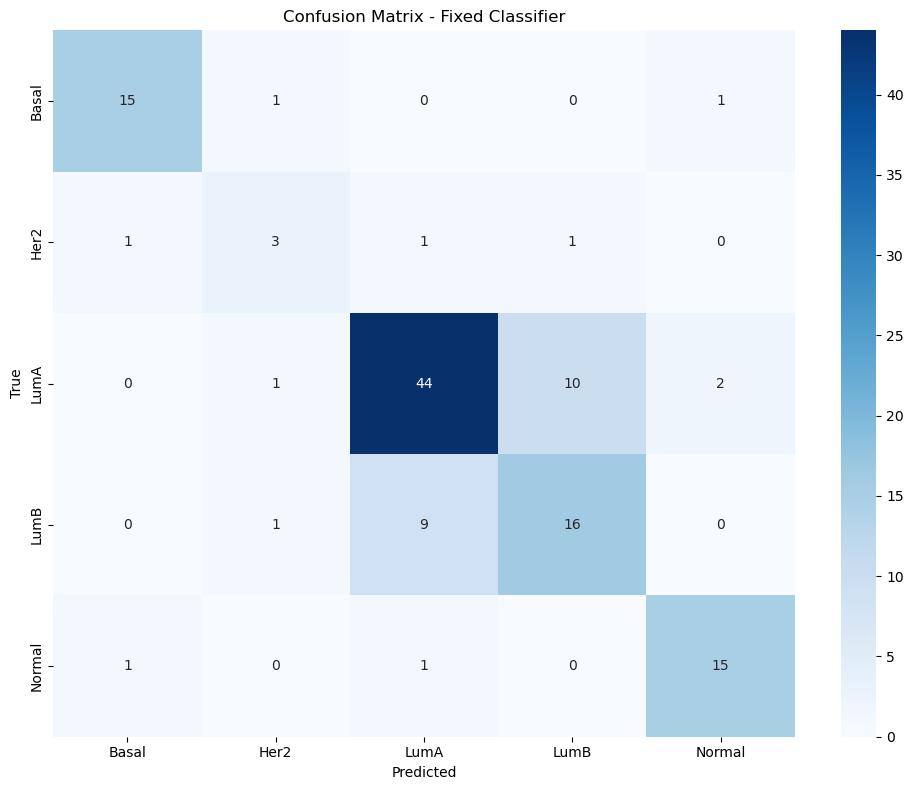

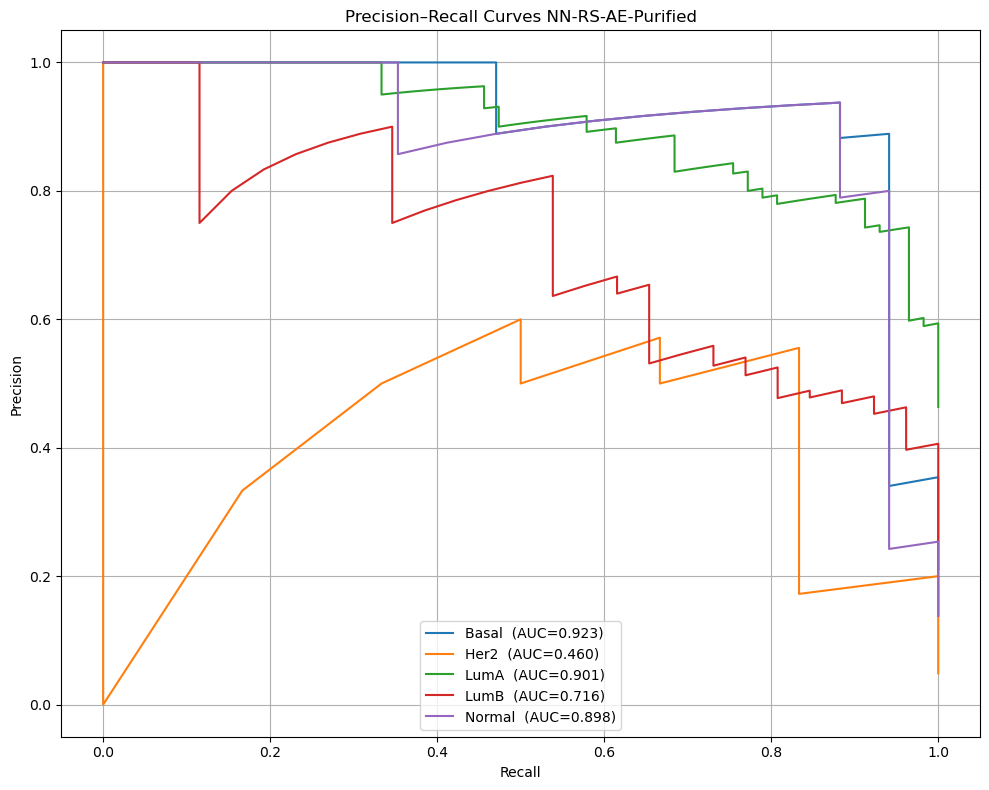

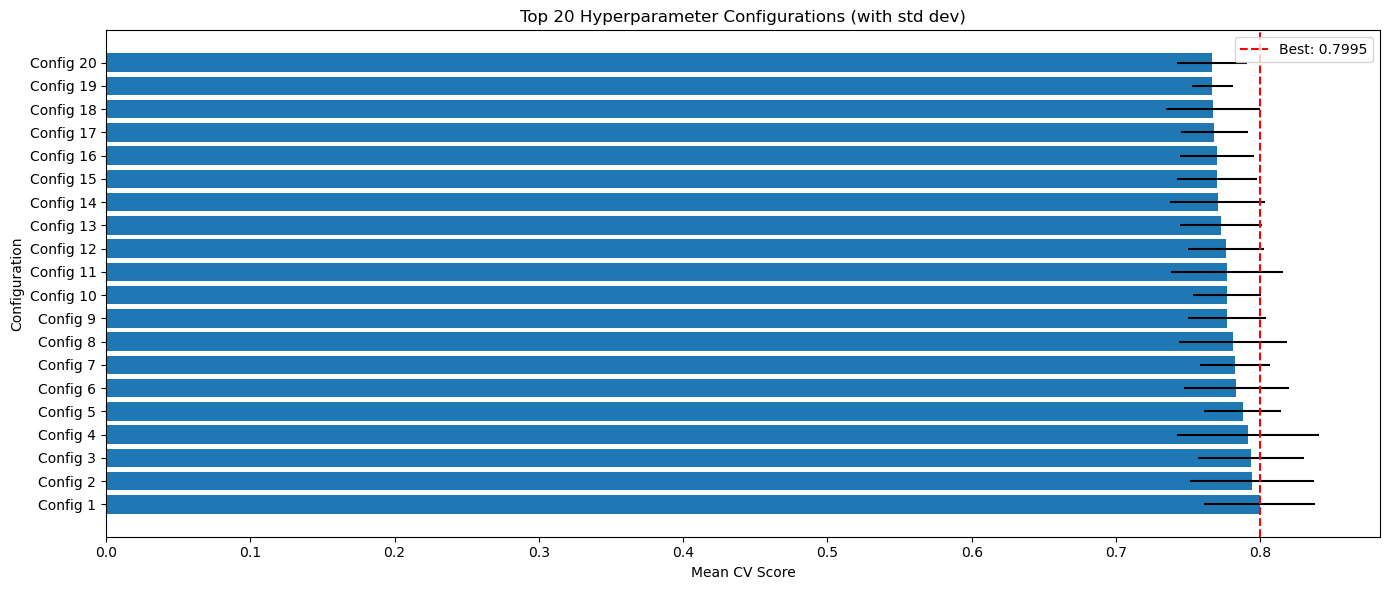


HYPERPARAMETER ANALYSIS:

model__activation:
  tanh: appears 7/10 times in top 10
  relu: appears 2/10 times in top 10
  leakyrelu: appears 1/10 times in top 10

model__learning_rate:
  0.0001: appears 7/10 times in top 10
  0.002: appears 2/10 times in top 10
  0.001: appears 1/10 times in top 10

batch_size:
  64: appears 5/10 times in top 10
  16: appears 3/10 times in top 10
  32: appears 2/10 times in top 10

model__dropout_rate1:
  0.1: appears 5/10 times in top 10
  0.3: appears 3/10 times in top 10
  0.2: appears 2/10 times in top 10

model__dropout_rate2:
  0.4: appears 4/10 times in top 10
  0.1: appears 3/10 times in top 10
  0.5: appears 2/10 times in top 10
  0.3: appears 1/10 times in top 10


C:\Users\Alvin\AppData\Local\Temp\ipykernel_27112\2211746725.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])


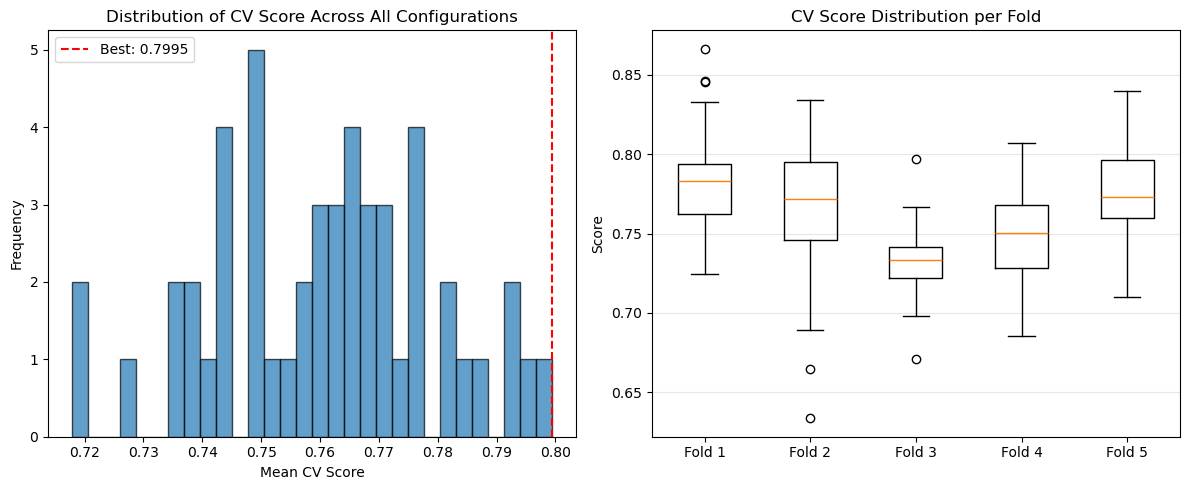


SUMMARY STATISTICS:
Best CV Score: 0.7995
Test Score: 0.7565
Mean CV Score (all configs): 0.7606
Std CV Score (all configs): 0.0191
Min CV Score: 0.7179
Max CV Score: 0.7995


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
from typing import Counter

test_acc = random_search.score(X_test_encoded, y_test_enc)

print(f"\nTest Score (Best Neural Network): {test_acc:.4f}")

# Predict probabilities and classes
y_pred_proba = best_model.predict_proba(X_test_encoded)
y_pred_classes = best_model.predict(X_test_encoded)

# -------------------------------
# CLASSIFICATION REPORT
# -------------------------------
print("\nClassification Report (Fixed Classifier):")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fixed Classifier')
plt.tight_layout()
plt.show()

# -------------------------------
# PRECISION–RECALL CURVES
# -------------------------------

# Predict probabilities for PR curve
y_pred_proba = best_model.predict_proba(X_test_encoded)

# Binarize labels for one-vs-rest PR curves
y_test_binarized = label_binarize(y_test_enc, classes=range(len(le.classes_)))

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_score = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name}  (AUC={auc_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves NN-RS-AE-Purified")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
#  Results Visualization
# ------------------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)

# Plot top 20 configurations
plt.figure(figsize=(14, 6))
top_20 = results_df.nsmallest(20, 'rank_test_score')

plt.barh(range(len(top_20)), top_20['mean_test_score'], xerr=top_20['std_test_score'])
plt.yticks(range(len(top_20)), [f"Config {i+1}" for i in range(len(top_20))])
plt.xlabel('Mean CV Score')
plt.ylabel('Configuration')
plt.title('Top 20 Hyperparameter Configurations (with std dev)')
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', label=f'Best: {random_search.best_score_:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Hyperparameter importance analysis
# ------------------------------------------------------------------

print("\n" + "="*80)
print("HYPERPARAMETER ANALYSIS:")
print("="*80)

top_10_configs = results_df.nsmallest(10, 'rank_test_score')

for param in ['model__activation', 
              'model__learning_rate', 'batch_size', 'model__dropout_rate1', 'model__dropout_rate2']:
    print(f"\n{param}:")
    param_values = [config[param] for config in top_10_configs['params']]
    counts = Counter(param_values)
    for value, count in counts.most_common():
        print(f"  {value}: appears {count}/10 times in top 10")

# ------------------------------------------------------------------
# CV Accuracy Distribution
# ------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Histogram of all CV Score
plt.subplot(1, 2, 1)
plt.hist(results_df['mean_test_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', 
            label=f'Best: {random_search.best_score_:.4f}')
plt.xlabel('Mean CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Score Across All Configurations')
plt.legend()

# Box plot (adjust to number of folds)
plt.subplot(1, 2, 2)
n_folds = random_search.cv.n_splits  # dynamically use actual folds
cv_scores = [results_df[f'split{i}_test_score'] for i in range(n_folds)]
plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])
plt.ylabel('Score')
plt.title('CV Score Distribution per Fold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS:")
print("="*80)
print(f"Best CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {test_acc:.4f}")
print(f"Mean CV Score (all configs): {results_df['mean_test_score'].mean():.4f}")
print(f"Std CV Score (all configs): {results_df['mean_test_score'].std():.4f}")
print(f"Min CV Score: {results_df['mean_test_score'].min():.4f}")
print(f"Max CV Score: {results_df['mean_test_score'].max():.4f}")

In [6]:


# If you used a Scikeras wrapper
print("\nBest Keras model parameters:")
print(best_model.get_params())


Best Keras model parameters:
{'model': <function create_classifier at 0x0000019BB9D8DE40>, 'build_fn': None, 'warm_start': False, 'random_state': 0, 'optimizer': 'rmsprop', 'loss': 'sparse_categorical_crossentropy', 'metrics': None, 'batch_size': 16, 'validation_batch_size': None, 'verbose': 0, 'callbacks': [<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000019E6D823BD0>, <__main__.HistoryLogger object at 0x0000019E6C2A3770>], 'validation_split': 0.0, 'shuffle': True, 'run_eagerly': False, 'epochs': 100, 'class_weight': None, 'model__learning_rate': 0.0001, 'model__hidden_dim': 200, 'model__dropout_rate2': 0.1, 'model__dropout_rate1': 0.3, 'model__activation': 'tanh'}


In [7]:
import shap
import lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, ReLU
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# ==========================================
# SETTINGS
# ==========================================
original_feature_names = X_train.columns.tolist()

MAX_BACKGROUND = 30
MAX_EXPLAIN = 30
SHAP_BATCH_SIZE = 10
RANDOM_STATE = 42
TOP_K = 10

OUT_DIR = "./explain_results"
os.makedirs(OUT_DIR, exist_ok=True)

# ==========================================
# BUILD AUTOENCODER (EXPLICIT DECODER)
# ==========================================
def build_autoencoder2(input_dim, encoding_dim=500, hidden_dim1=5000, hidden_dim2=2000,
                      l2_reg=1e-14, learning_rate=3e-5):
    # Encoder
    inp = Input(shape=(input_dim,))
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = ReLU()(x)
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    encoded = Dense(encoding_dim, kernel_regularizer=regularizers.l2(l2_reg))(x)
    encoded_act = ReLU()(encoded)

    # Decoder
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(encoded_act)
    x = ReLU()(x)
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    decoded = Dense(input_dim, activation='linear')(x)

    autoencoder2 = Model(inp, decoded)
    encoder2 = Model(inp, encoded_act)

    # Explicit decoder model
    encoded_input = Input(shape=(encoding_dim,))
    d = autoencoder2.layers[-6](encoded_input)  # first decoder Dense
    d = autoencoder2.layers[-5](d)             # first ReLU
    d = autoencoder2.layers[-4](d)             # second decoder Dense
    d = autoencoder2.layers[-3](d)             # second ReLU
    d = autoencoder2.layers[-2](d)             # output Dense
    decoder2 = Model(encoded_input, d)

    autoencoder2.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return autoencoder2, encoder2, decoder2

# Assume input_dim is known
autoencoder2, encoder2, decoder2 = build_autoencoder2(input_dim)

# ==========================================
# MODEL EXTRACTION
# ==========================================
print("\n[MODEL] Extracting best Keras model...")
keras_model = None
try:
    keras_model = getattr(best_model, "model_", None)
    if keras_model is None:
        keras_model = best_model.named_steps.get("nn").model_
except Exception:
    keras_model = best_model  # fallback

if keras_model is None:
    raise ValueError("Could not extract Keras model from best_model!")

print("Using Keras model:", type(keras_model))
print(f"Model input shape: {keras_model.input_shape}")

# ==========================================
# USE ENCODED DATA FOR SHAP
# ==========================================
if isinstance(X_train_encoded, pd.DataFrame):
    X_train_arr = X_train_encoded.values
    X_test_arr = X_test_encoded.values
else:
    X_train_arr = X_train_encoded
    X_test_arr = X_test_encoded

feature_names_encoded = [f"Encoded_{i}" for i in range(X_train_arr.shape[1])]
print(f"Using {len(feature_names_encoded)} encoded features")

# ==========================================
# SHAP EXPLANATIONS
# ==========================================
def shap_sample_fallback(X, n, random_state):
    if hasattr(shap, "sample"):
        return shap.sample(X, n, random_state=random_state)
    else:
        idx = np.random.RandomState(random_state).choice(len(X), size=n, replace=False)
        return X[idx]

small_bg = shap_sample_fallback(X_train_arr, min(MAX_BACKGROUND, len(X_train_arr)), RANDOM_STATE)
small_test = shap_sample_fallback(X_test_arr, min(MAX_EXPLAIN, len(X_test_arr)), RANDOM_STATE)

try:
    print("Attempting DeepExplainer...")
    explainer = shap.DeepExplainer(keras_model, small_bg)
    shap_values = explainer.shap_values(small_test, check_additivity=False)
    expected_value = explainer.expected_value
    use_deep = True
except Exception as e:
    print(f"DeepExplainer failed: {e}")
    print("→ Using KernelExplainer with batch processing...")
    def model_wrapper(X):
        return keras_model.predict(X, batch_size=32, verbose=0)
    explainer = shap.KernelExplainer(model_wrapper, small_bg)
    shap_values_list = []
    total_batches = int(np.ceil(len(small_test) / SHAP_BATCH_SIZE))
    for i in range(0, len(small_test), SHAP_BATCH_SIZE):
        batch_end = min(i + SHAP_BATCH_SIZE, len(small_test))
        batch = small_test[i:batch_end]
        batch_shap = explainer.shap_values(batch)
        shap_values_list.append(batch_shap)
        gc.collect()
    if isinstance(shap_values_list[0], list):
        n_classes = len(shap_values_list[0])
        shap_values = [np.vstack([b[c] for b in shap_values_list]) for c in range(n_classes)]
    else:
        shap_values = np.vstack(shap_values_list)
    expected_value = explainer.expected_value
    use_deep = False

del explainer
gc.collect()

if isinstance(shap_values, list):
    shap_values = np.stack([np.array(s) for s in shap_values], axis=2)

# ==========================================
# OVERALL SHAP IMPORTANCE
# ==========================================
if shap_values.ndim == 3:
    shap_values_overall = np.abs(shap_values).max(axis=2)
else:
    shap_values_overall = np.abs(shap_values)

mean_abs_shap_overall = shap_values_overall.mean(axis=0)
shap_importances_overall = pd.DataFrame({
    "Feature": feature_names_encoded,
    "MeanAbsSHAP_MaxAcrossClasses": mean_abs_shap_overall
}).sort_values(by="MeanAbsSHAP_MaxAcrossClasses", ascending=False)

top_features_overall = shap_importances_overall.head(TOP_K)
top_features_overall.to_csv(os.path.join(OUT_DIR, "top_features_overall_max.csv"), index=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features_overall,
            x="MeanAbsSHAP_MaxAcrossClasses",
            y="Feature",
            palette="Greens_d")
plt.title("Top 10 SHAP Encoded Features (Overall)")
plt.xlabel("Mean |SHAP| Value")
plt.ylabel("Encoded Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top10_overall_bar.png"), dpi=150)
plt.close()

print("\n=== Top 10 Encoded Features (Overall) ===")
print(top_features_overall)

# ==========================================
# DECODE SHAP VALUES TO ORIGINAL SPACE
# ==========================================
def decode_shap_values(shap_values_encoded, autoencoder, encoding_dim, original_dim):
    """
    Approximate decoding of SHAP values from encoded space to original feature space.
    Uses decoder weights to map SHAP values back.
    
    Parameters:
        shap_values_encoded: np.array, SHAP values in encoded space
        autoencoder: trained Keras autoencoder
        encoding_dim: int, size of encoded vector
        original_dim: int, number of original features
    """
    # Build decoder input
    from tensorflow.keras.layers import Input
    from tensorflow.keras.models import Model

    encoded_input = Input(shape=(encoding_dim,))
    
    # Manually get decoder layers (assume your autoencoder is structured like yours)
    # Here we use all layers after the encoded layer
    decoder_layers = autoencoder.layers[-6:]  # adjust according to your autoencoder
    
    x = encoded_input
    for layer in decoder_layers:
        x = layer(x)
    decoder_model = Model(encoded_input, x)

    # Propagate SHAP values through decoder using weights
    decoded_shap = shap_values_encoded.copy()
    for layer in decoder_layers:
        if hasattr(layer, "get_weights") and len(layer.get_weights()) > 0:
            W, b = layer.get_weights()
            decoded_shap = np.dot(decoded_shap, W)
            # Apply ReLU if exists
            if hasattr(layer, "activation") and layer.activation.__name__ == "relu":
                decoded_shap = np.maximum(decoded_shap, 0)
    
    # Truncate/pad to match original feature size
    decoded_shap = decoded_shap[:, :original_dim]
    return decoded_shap


encoding_dim = 500  # match your autoencoder's encoding_dim
original_dim = X_train.shape[1]

decoded_shap_full = decode_shap_values(shap_values_overall, autoencoder, encoding_dim, original_dim)
decoded_importance = np.mean(np.abs(decoded_shap_full), axis=0)

decoded_df = pd.DataFrame({
    "Feature": original_feature_names,  # your original feature names
    "ApproxMeanAbsSHAP": decoded_importance
}).sort_values(by="ApproxMeanAbsSHAP", ascending=False)


decoded_df.to_csv(os.path.join(OUT_DIR, "decoded_shap_features.csv"), index=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=decoded_df.head(TOP_K),
    x="ApproxMeanAbsSHAP",
    y="Feature",
    palette="Blues_d"
)
plt.title("Top 10 Original Features (Decoded SHAP Approximation)")
plt.xlabel("Approx. Mean |SHAP| Value")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top10_decoded_bar.png"), dpi=150)
plt.close()

# ==========================================
# EXTRACT CLASS LABELS
# ==========================================
try:
    # Try to get class names from the model or label encoder
    if hasattr(best_model, 'classes_'):
        class_names = best_model.classes_.tolist()
    elif hasattr(best_model, 'named_steps') and 'nn' in best_model.named_steps:
        if hasattr(best_model.named_steps['nn'], 'classes_'):
            class_names = best_model.named_steps['nn'].classes_.tolist()
        else:
            class_names = None
    else:
        class_names = None
    
    # Fallback to y_train unique values if available
    if class_names is None and 'y_train' in globals():
        class_names = sorted(y_train.unique().tolist())
    
    print(f"[SHAP] Detected class names: {class_names}")
except Exception as e:
    print(f"[SHAP] Could not extract class names: {e}")
    class_names = None

# ==========================================
# SHAP SUMMARY PLOTS FOR EACH CLASS
# ==========================================
if shap_values.ndim == 3:
    n_classes = shap_values.shape[2]
    print(f"\n[SHAP] Creating summary plots for {n_classes} classes...")
    
    for class_idx in range(n_classes):
        class_label = class_names[class_idx] if class_names else f"Class {class_idx}"
    for class_idx in range(n_classes):
        class_label = class_names[class_idx] if class_names else f"Class {class_idx}"
        class_shap = shap_values[:, :, class_idx]
        
        # Summary plot (beeswarm)
        plt.figure(figsize=(12, 10))
        shap.summary_plot(
            class_shap,
            small_test,
            feature_names=feature_names_encoded,
            max_display=TOP_K,
            show=False
        )
        plt.title(f"SHAP Summary Plot - {class_label}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"shap_summary_{class_label.lower().replace(' ', '_')}.png"), dpi=150, bbox_inches='tight')
        plt.close()
        
        # Bar plot (mean absolute SHAP)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            class_shap,
            small_test,
            feature_names=feature_names_encoded,
            max_display=TOP_K,
            plot_type="bar",
            show=False
        )
        plt.title(f"SHAP Feature Importance - {class_label}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"shap_bar_{class_label.lower().replace(' ', '_')}.png"), dpi=150, bbox_inches='tight')
        plt.close()
        
        # Save class-specific importance
        mean_abs_shap_class = np.abs(class_shap).mean(axis=0)
        class_importance = pd.DataFrame({
            "Feature": feature_names_encoded,
            "MeanAbsSHAP": mean_abs_shap_class
        }).sort_values(by="MeanAbsSHAP", ascending=False)
        class_importance.to_csv(os.path.join(OUT_DIR, f"top_features_{class_label.lower().replace(' ', '_')}.csv"), index=False)
        
        print(f"  ✓ {class_label} summary plots saved")
    
    print(f"\n✓ Summary plots for all {n_classes} classes completed")
else:
    # Binary classification or regression
    print("\n[SHAP] Creating summary plot (single output)...")
    
    plt.figure(figsize=(12, 10))
    shap.summary_plot(
        shap_values,
        small_test,
        feature_names=feature_names_encoded,
        max_display=TOP_K,
        show=False
    )
    plt.title("SHAP Summary Plot", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "shap_summary.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        small_test,
        feature_names=feature_names_encoded,
        max_display=TOP_K,
        plot_type="bar",
        show=False
    )
    plt.title("SHAP Feature Importance", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "shap_bar.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    print("  ✓ Summary plots saved")

print("\n✅ SHAP analysis complete and decoded to original feature space.")
print(f"Results saved to: {OUT_DIR}")
print("Note: Decoded SHAP values are approximate due to nonlinear decoder layers.")

NameError: name 'input_dim' is not defined